# 🏠 Robust Regression Engine

**Goal:** build a robust regression pipeline using regularization, cross-validation, tree-based models and Support Vector Regression, then compare models on unseen data and prepare a business-oriented conclusion.

> Dataset: 3,800 real-estate records with a continuous target `house_price_inr`.

# Dataset Understanding & Preparation 

In [12]:
# import librraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, LeaveOneOut, TimeSeriesSplit,
    cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import TransformedTargetRegressor
import time
import json
from pathlib import Path

In [3]:
# Data Loading

df = pd.read_excel("C:/Users/MR_MAHESH/Downloads/Advanced_Regression_HousePrice_Dataset_3800.xlsx")
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


# 
**Identify features and target variable.**

In [4]:
df.shape

(3800, 12)

In [5]:
print('Columns:')
print(df.columns.tolist())

Columns:
['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'house_price_inr']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   property_id       3800 non-null   int64         
 1   sale_date         3800 non-null   datetime64[ns]
 2   area_sqft         3800 non-null   int64         
 3   bedrooms          3800 non-null   int64         
 4   bathrooms         3800 non-null   int64         
 5   location_score    3800 non-null   float64       
 6   property_age      3800 non-null   int64         
 7   distance_city_km  3800 non-null   float64       
 8   near_school       3800 non-null   int64         
 9   near_metro        3800 non-null   int64         
 10  crime_rate_index  3800 non-null   float64       
 11  house_price_inr   3800 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 356.4 KB


In [7]:
# Convert date into useful numerical time features. Raw datetime is not passed directly to the models.
df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month

#
**Perform a train–test split.**

In [9]:
target = 'house_price_inr'
feature_columns = [
    'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
    'property_age', 'distance_city_km', 'near_school', 'near_metro',
    'crime_rate_index', 'sale_year', 'sale_month'
]

X = df[feature_columns].copy()
y = df[target].copy()

print('\nTarget:', target)
print('\nFeatures:')
print(feature_columns)
print('\nX shape:', X.shape)
print('y shape:', y.shape)


Target: house_price_inr

Features:
['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'sale_year', 'sale_month']

X shape: (3800, 11)
y shape: (3800,)


In [14]:
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print('Training rows:', X_train.shape[0])
print('Testing rows :', X_test.shape[0])

Training rows: 3040
Testing rows : 760


#
**Apply Basic Preprocessing (Scaling where required)**

In [15]:
# Pipelines will perform scaling only where it is appropriate.
scaled_example = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

tree_example = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=8)

print('Scaled models: Ridge, Lasso, SVR')
print('Unscaled models: Decision Tree, Random Forest')

Scaled models: Ridge, Lasso, SVR
Unscaled models: Decision Tree, Random Forest


# Regularized Linear Models

#
**Implement Ridge Regression (L2)**

In [16]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
ridge_pipe.fit(X_train, y_train)
ridge_pred = ridge_pipe.predict(X_test)

print('Ridge model trained successfully.')
print('Test R²:', round(r2_score(y_test, ridge_pred), 4))

Ridge model trained successfully.
Test R²: 0.9199


#
**Implement Lasso Regression (L1)**

In [17]:
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01, max_iter=50000))
])
lasso_pipe.fit(X_train, y_train)
lasso_pred = lasso_pipe.predict(X_test)

print('Lasso model trained successfully.')
print('Test R²:', round(r2_score(y_test, lasso_pred), 4))

Lasso model trained successfully.
Test R²: 0.9199


#
**Tune the Regularization Parameter (α) using Cross-Validation**

In [18]:
alpha_grid = np.logspace(-3, 4, 12)

# Ridge tuning
ridge_search = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())]),
    param_grid={'ridge__alpha': alpha_grid},
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1
)
ridge_search.fit(X_train, y_train)

# Lasso tuning
lasso_search = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(max_iter=100000))]),
    param_grid={'lasso__alpha': alpha_grid},
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1
)
lasso_search.fit(X_train, y_train)

print('Best Ridge alpha:', ridge_search.best_params_['ridge__alpha'])
print('Best Lasso alpha:', lasso_search.best_params_['lasso__alpha'])
print('Best Ridge CV RMSE:', round(-ridge_search.best_score_, 2))
print('Best Lasso CV RMSE:', round(-lasso_search.best_score_, 2))

Best Ridge alpha: 0.3511191734215131
Best Lasso alpha: 10000.0
Best Ridge CV RMSE: 2491842.72
Best Lasso CV RMSE: 2491389.6


#
**Compare Ridge and Lasso based on Training Error, Validation Error and Coefficient Behavior**

In [19]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MSE': mse,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_true, y_pred)
    }

ridge_best = ridge_search.best_estimator_
lasso_best = lasso_search.best_estimator_

ridge_train_pred = ridge_best.predict(X_train)
ridge_test_pred = ridge_best.predict(X_test)
lasso_train_pred = lasso_best.predict(X_train)
lasso_test_pred = lasso_best.predict(X_test)

ridge_m = regression_metrics(y_test, ridge_test_pred)
lasso_m = regression_metrics(y_test, lasso_test_pred)

comparison = pd.DataFrame([
    ['Ridge', regression_metrics(y_train, ridge_train_pred)['RMSE'], ridge_m['RMSE'], ridge_m['R2']],
    ['Lasso', regression_metrics(y_train, lasso_train_pred)['RMSE'], lasso_m['RMSE'], lasso_m['R2']]
], columns=['Model', 'Training RMSE', 'Test RMSE', 'Test R2'])
display(comparison)

coef_table = pd.DataFrame({
    'Feature': feature_columns,
    'Ridge_Coefficient': ridge_best.named_steps['ridge'].coef_,
    'Lasso_Coefficient': lasso_best.named_steps['lasso'].coef_
})
display(coef_table.sort_values('Lasso_Coefficient'))

print('Number of exact-zero Lasso coefficients:', int(np.sum(lasso_best.named_steps['lasso'].coef_ == 0)))

,Model,Training RMSE,Test RMSE,Test R2
0,Ridge,2.482395e+06,2.539794e+06,0.919904
1,Lasso,2.482563e+06,2.541785e+06,0.919778


,Feature,Ridge_Coefficient,Lasso_Coefficient
4,property_age,-6.500594e+05,-6.410389e+05
8,crime_rate_index,-1.406491e+05,-1.310758e+05
5,distance_city_km,-2.763029e+04,-2.064623e+04
6,near_school,1.567729e+04,5.220128e+03
10,sale_month,1.739906e+04,7.208987e+03
7,near_metro,5.260329e+04,4.277984e+04
2,bathrooms,2.731267e+05,2.678382e+05
1,bedrooms,2.912985e+05,2.890343e+05
9,sale_year,3.010844e+05,2.912458e+05
3,location_score,3.680072e+06,3.675390e+06


Number of exact-zero Lasso coefficients: 0


<Figure size 1200x600 with 0 Axes>

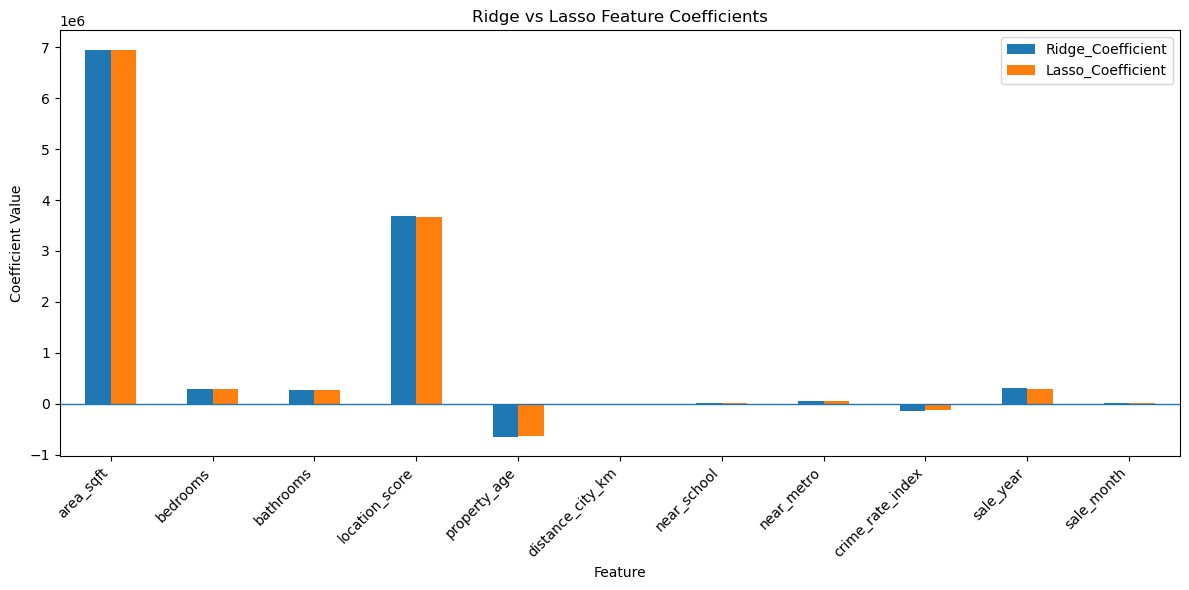

The coefficient comparison shows how L2 and L1 regularization affect feature weights. Ridge generally shrinkscoefficients smoothly, while Lasso can drive less useful coefficients exactly to zero. This graph helps visualize regularizationstrength and feature-selection behavior.


In [21]:
plt.figure(figsize=(12, 6))
coef_plot = coef_table.set_index('Feature')
coef_plot[['Ridge_Coefficient', 'Lasso_Coefficient']].plot(kind='bar', figsize=(12, 6))
plt.axhline(0, linewidth=1)
plt.title('Ridge vs Lasso Feature Coefficients')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("The coefficient comparison shows how L2 and L1 regularization affect feature weights. Ridge generally shrinkscoefficients smoothly, while Lasso can drive less useful coefficients exactly to zero. This graph helps visualize regularizationstrength and feature-selection behavior.")

# Cross-Validation Strategies

#
**Apply and Compare Cross-Validation Strategies**

In [22]:
cv_model = Pipeline([('scaler', StandardScaler()), 
                     ('ridge', Ridge(alpha=ridge_search.best_params_['ridge__alpha']))])

In [28]:
# 1) K-Fold Cross-Validation 

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
kfold_scores = -cross_val_score(cv_model, X_train, y_train, cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
print(kfold_scores)

[2480600.51000561 2664338.02185725 2473869.07461708 2403635.13938668
 2453884.90481335]


In [29]:
# 2) Stratified K-Fold for regression by binning the continuous target

y_bins = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
stratified_scores = -cross_val_score(cv_model, X_train, y_train, cv=skf.split(X_train, y_bins), scoring='neg_root_mean_squared_error', n_jobs=-1)
print(stratified_scores)

[2547774.8716791  2445688.56695656 2425615.50010934 2419247.95910501
 2616437.68677706]


In [30]:
# 3) LOOCV

start = time.perf_counter()
loocv_scores = -cross_val_score(cv_model, X_train, y_train, cv=LeaveOneOut(), scoring='neg_root_mean_squared_error', n_jobs=-1)
loocv_time = time.perf_counter() - start
print(loocv_scores)

[ 702886.87222447 3423127.33227892  753494.27780695 ... 1928315.63146336
  747156.6138943  2394469.301609  ]


In [31]:
# 4) Time Series Split. Sort by sale date first so validation always occurs after training data.

sorted_idx = df.loc[X_train.index].sort_values('sale_date').index
X_time = X.loc[sorted_idx]
y_time = y.loc[sorted_idx]
tscv = TimeSeriesSplit(n_splits=5)
time_scores = -cross_val_score(cv_model, X_time, y_time, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
print(time_scores)

[2681283.75315798 2498759.60069139 2349014.32644164 2425530.64768136
 2516915.64647547]


In [32]:
cv_results = pd.DataFrame({
    'CV Strategy': ['K-Fold', 'Stratified K-Fold', 'LOOCV', 'Time Series Split'],
    'Mean RMSE': [kfold_scores.mean(), stratified_scores.mean(), loocv_scores.mean(), time_scores.mean()],
    'Std RMSE': [kfold_scores.std(), stratified_scores.std(), loocv_scores.std(), time_scores.std()],
    'Approx. Time (sec)': [np.nan, np.nan, loocv_time, np.nan]
})
display(cv_results)
print('LOOCV completed in', round(loocv_time, 2), 'seconds.')

,CV Strategy,Mean RMSE,Std RMSE,Approx. Time (sec)
0,K-Fold,2.495266e+06,8.873203e+04,NaN
1,Stratified K-Fold,2.490953e+06,7.801872e+04,NaN
2,LOOCV,1.904818e+06,1.608438e+06,11.618641
3,Time Series Split,2.494301e+06,1.107533e+05,NaN


LOOCV completed in 11.62 seconds.


#
**Analyze how Performance Metrics vary across CV Strategies**

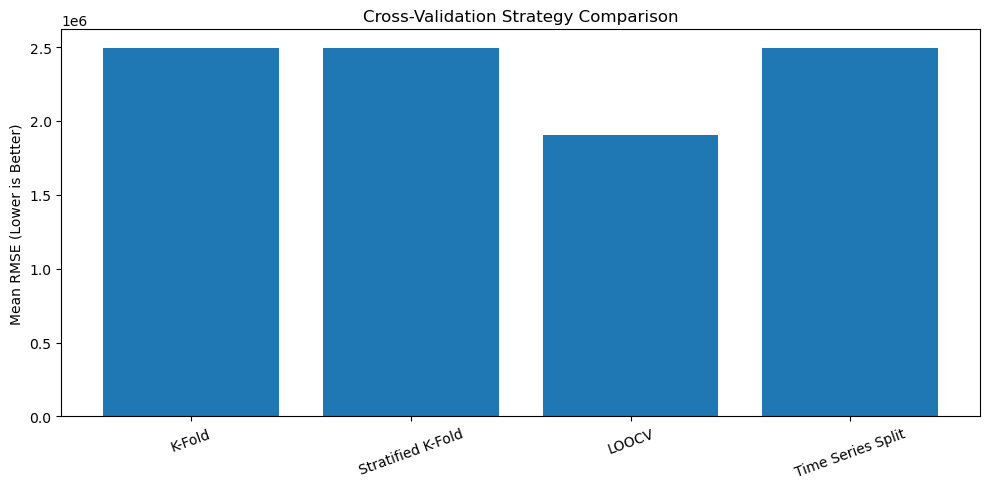

Interpretation: lower mean RMSE indicates lower average validation error. Time Series Split can differ because it respects chronological ordering, while random K-Fold mixes observations across time.


In [33]:
plt.figure(figsize=(10, 5))
plt.bar(cv_results['CV Strategy'], cv_results['Mean RMSE'])
plt.title('Cross-Validation Strategy Comparison')
plt.ylabel('Mean RMSE (Lower is Better)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print('Interpretation: lower mean RMSE indicates lower average validation error. Time Series Split can differ because it respects chronological ordering, while random K-Fold mixes observations across time.')

# Tree-Based Regression Models 

#
**Implement Decision Tree Regression.**

In [34]:
dt = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_param_grid = {
    'max_depth': [3, 5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

dt_search = GridSearchCV(dt, dt_param_grid, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
dt_search.fit(X_train, y_train)

print('Best Decision Tree parameters:', dt_search.best_params_)
print('Best CV RMSE:', round(-dt_search.best_score_, 2))

Best Decision Tree parameters: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV RMSE: 2806263.24


#
**Control tree complexity using hyperparameters (max depth, min samples).**

,max_depth,Train_R2,Test_R2
0,2,0.650597,0.639541
1,4,0.854712,0.844441
2,6,0.920481,0.898213
3,8,0.950502,0.900443
4,10,0.971791,0.888632
5,15,0.983021,0.882813
6,None,0.983073,0.882199


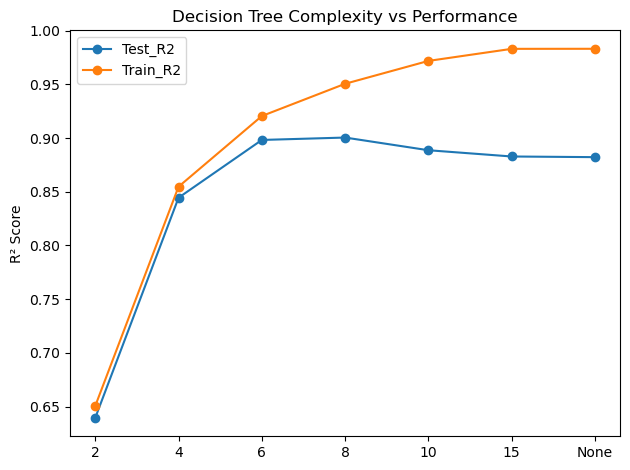

The graph shows how changing tree depth affects training and test R². A large gap between training and test performance is a warning sign of high variance and possible overfitting. Restricting depth or increasing minimum samples can control tree complexity.


In [36]:
depth_values = [2, 4, 6, 8, 10, 15, None]
rows = []
for depth in depth_values:
    model = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=3, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    rows.append({
        'max_depth': str(depth),
        'Train_R2': r2_score(y_train, model.predict(X_train)),
        'Test_R2': r2_score(y_test, model.predict(X_test))
    })

depth_df = pd.DataFrame(rows)
display(depth_df)

depth_plot = depth_df.melt(id_vars='max_depth', value_vars=['Train_R2', 'Test_R2'], var_name='Dataset', value_name='R2')

for label, group in depth_plot.groupby('Dataset'):
    plt.plot(group['max_depth'], group['R2'], marker='o', label=label)
plt.legend()
plt.title('Decision Tree Complexity vs Performance')
plt.ylabel('R² Score')
plt.tight_layout()
plt.show()

print("The graph shows how changing tree depth affects training and test R². A large gap between training and test performance is a warning sign of high variance and possible overfitting. Restricting depth or increasing minimum samples can control tree complexity.")

#
**Implement Random Forest Regression**

In [37]:
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
rf_param_dist = {
    'n_estimators': [150, 250],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [0.7, 1.0]
}

rf_search = RandomizedSearchCV(
    rf, rf_param_dist, n_iter=10, scoring='neg_root_mean_squared_error',
    cv=5, random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train, y_train)

print('Best Random Forest parameters:', rf_search.best_params_)
print('Best CV RMSE:', round(-rf_search.best_score_, 2))

Best Random Forest parameters: {'n_estimators': 250, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20}
Best CV RMSE: 2354735.19


#
**Compare single-tree vs ensemble performance**

In [38]:
dt_best = dt_search.best_estimator_
rf_best = rf_search.best_estimator_

models_tree = {'Decision Tree': dt_best, 'Random Forest': rf_best}
tree_rows = []
for name, model in models_tree.items():
    pred_tr = model.predict(X_train)
    pred_te = model.predict(X_test)
    tree_rows.append({
        'Model': name,
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, pred_tr)),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, pred_te)),
        'Test_MAE': mean_absolute_error(y_test, pred_te),
        'Test_R2': r2_score(y_test, pred_te)
    })

tree_comparison = pd.DataFrame(tree_rows)
display(tree_comparison)

print('Random Forest combines many trees and can reduce the variance of a single decision tree through ensemble averaging.')

,Model,Train_RMSE,Test_RMSE,Test_MAE,Test_R2
0,Decision Tree,1.983854e+06,2.812470e+06,2.065624e+06,0.901782
1,Random Forest,1.403780e+06,2.378443e+06,1.734242e+06,0.929757


Random Forest combines many trees and can reduce the variance of a single decision tree through ensemble averaging.


# Support Vector Regression 

#
**Implement Support Vector Regression with Linear and RBF Kernels**

In [40]:
svr_linear = TransformedTargetRegressor(
    regressor=Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='linear'))]),
    transformer=StandardScaler()
)
svr_rbf = TransformedTargetRegressor(
    regressor=Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf'))]),
    transformer=StandardScaler()
)

svr_linear.fit(X_train, y_train)
svr_rbf.fit(X_train, y_train)

print('Linear-kernel SVR Test R²:', round(r2_score(y_test, svr_linear.predict(X_test)), 4))
print('RBF-kernel SVR Test R²:', round(r2_score(y_test, svr_rbf.predict(X_test)), 4))

Linear-kernel SVR Test R²: 0.9184
RBF-kernel SVR Test R²: 0.9227


#
**Tune hyperparameters (C, γ, ε).**

In [41]:
svr_param_grid = {
    'regressor__svr__C': [0.1, 1, 10, 100],
    'regressor__svr__gamma': ['scale', 0.01, 0.1],
    'regressor__svr__epsilon': [0.01, 0.1, 0.2]
}

svr_rbf_search = GridSearchCV(
    TransformedTargetRegressor(
        regressor=Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf'))]),
        transformer=StandardScaler()
    ),
    param_grid=svr_param_grid, scoring='neg_root_mean_squared_error',
    cv=3, n_jobs=-1
)
svr_rbf_search.fit(X_train, y_train)

print('Best SVR parameters:', svr_rbf_search.best_params_)
print('Best SVR CV RMSE:', round(-svr_rbf_search.best_score_, 2))

Best SVR parameters: {'regressor__svr__C': 10, 'regressor__svr__epsilon': 0.1, 'regressor__svr__gamma': 0.01}
Best SVR CV RMSE: 2223734.67


#
**Compare SVR with Linear and Tree-Based Models**

In [42]:
svr_best = svr_rbf_search.best_estimator_
svr_models = {
    'SVR Linear': svr_linear,
    'SVR RBF': svr_best,
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'Ridge': ridge_best,
    'Lasso': lasso_best
}

rows = []
for name, model in svr_models.items():
    pred = model.predict(X_test)
    rows.append({
        'Model': name,
        'MSE': mean_squared_error(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred)
    })

svr_comparison = pd.DataFrame(rows).sort_values('RMSE')
display(svr_comparison)

,Model,MSE,MAE,RMSE,R2
1,SVR RBF,5.027679e+12,1.637712e+06,2.242249e+06,0.937572
3,Random Forest,5.656993e+12,1.734242e+06,2.378443e+06,0.929757
4,Ridge,6.450552e+12,1.945473e+06,2.539794e+06,0.919904
5,Lasso,6.460669e+12,1.946171e+06,2.541785e+06,0.919778
0,SVR Linear,6.572326e+12,1.938630e+06,2.563655e+06,0.918392
2,Decision Tree,7.909989e+12,2.065624e+06,2.812470e+06,0.901782


# Model Comparison & Evaluation

#
**Evaluate all Models using MSE, MAE, RMSE and R²**

In [43]:
linear_baseline = LinearRegression()
linear_baseline.fit(X_train, y_train)

all_models = {
    'Linear Regression': linear_baseline,
    'Ridge': ridge_best,
    'Lasso': lasso_best,
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'SVR Linear': svr_linear,
    'SVR RBF': svr_best
}

all_rows = []
for name, model in all_models.items():
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    all_rows.append({
        'Model': name,
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, pred_train)),
        'Test_MSE': mean_squared_error(y_test, pred_test),
        'Test_MAE': mean_absolute_error(y_test, pred_test),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, pred_test)),
        'Test_R2': r2_score(y_test, pred_test),
        'R2_Gap': r2_score(y_train, pred_train) - r2_score(y_test, pred_test)
    })

results = pd.DataFrame(all_rows).sort_values('Test_RMSE').reset_index(drop=True)
display(results)

results.to_csv('outputs/model_comparison.csv', index=False)

,Model,Train_RMSE,Test_MSE,Test_MAE,Test_RMSE,Test_R2,R2_Gap
0,SVR RBF,2.117488e+06,5.027679e+12,1.637712e+06,2.242249e+06,0.937572,0.002329
1,Random Forest,1.403780e+06,5.656993e+12,1.734242e+06,2.378443e+06,0.929757,0.043829
2,Linear Regression,2.482395e+06,6.450122e+12,1.945520e+06,2.539709e+06,0.919909,-0.002507
3,Ridge,2.482395e+06,6.450552e+12,1.945473e+06,2.539794e+06,0.919904,-0.002502
4,Lasso,2.482563e+06,6.460669e+12,1.946171e+06,2.541785e+06,0.919778,-0.002388
5,SVR Linear,2.495245e+06,6.572326e+12,1.938630e+06,2.563655e+06,0.918392,-0.001847
6,Decision Tree,1.983854e+06,7.909989e+12,2.065624e+06,2.812470e+06,0.901782,0.045465


#
**Compare Regularized Linear Models, Tree-Based Models and SVR**

,Model Family,Mean_Test_RMSE,Mean_Test_R2
2,SVR,2.402952e+06,0.927982
0,Linear,2.539709e+06,0.919909
1,Regularized Linear,2.540789e+06,0.919841
3,Tree-Based,2.595457e+06,0.915770


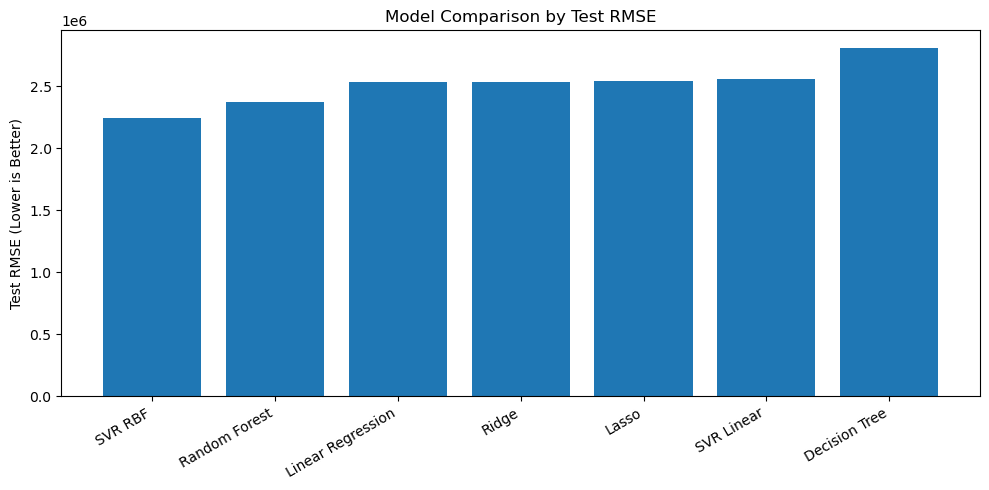

The model comparison graph shows the test RMSE for each regression algorithm. Lower RMSE means smaller prediction error on the held-out test data. The graph is used together with R², MAE and train-test gaps rather than as a standalone selection rule.


In [45]:
results['Model Family'] = results['Model'].map({
    'Linear Regression': 'Linear',
    'Ridge': 'Regularized Linear',
    'Lasso': 'Regularized Linear',
    'Decision Tree': 'Tree-Based',
    'Random Forest': 'Tree-Based',
    'SVR Linear': 'SVR',
    'SVR RBF': 'SVR'
})

family_summary = results.groupby('Model Family', as_index=False).agg(
    Mean_Test_RMSE=('Test_RMSE', 'mean'),
    Mean_Test_R2=('Test_R2', 'mean')
).sort_values('Mean_Test_RMSE')

display(family_summary)

plt.figure(figsize=(10, 5))
plt.bar(results['Model'], results['Test_RMSE'])
plt.title('Model Comparison by Test RMSE')
plt.ylabel('Test RMSE (Lower is Better)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("The model comparison graph shows the test RMSE for each regression algorithm. Lower RMSE means smaller prediction error on the held-out test data. The graph is used together with R², MAE and train-test gaps rather than as a standalone selection rule.")

#
**Identify Signs of Overfitting or Underfitting in Each Model**

In [46]:
diagnosis = results[['Model', 'Train_RMSE', 'Test_RMSE', 'Test_R2', 'R2_Gap']].copy()

def diagnose(row):
    if row['R2_Gap'] > 0.10 and row['Train_RMSE'] < row['Test_RMSE'] * 0.7:
        return 'Possible Overfitting'
    if row['Test_R2'] < 0.50:
        return 'Possible Underfitting / Weak Fit'
    return 'Reasonable Generalization'

diagnosis['Diagnosis'] = diagnosis.apply(diagnose, axis=1)
display(diagnosis)

print('Interpretation: a large train-test performance gap suggests high variance; weak performance on both training and test data suggests high bias.')

,Model,Train_RMSE,Test_RMSE,Test_R2,R2_Gap,Diagnosis
0,SVR RBF,2.117488e+06,2.242249e+06,0.937572,0.002329,Reasonable Generalization
1,Random Forest,1.403780e+06,2.378443e+06,0.929757,0.043829,Reasonable Generalization
2,Linear Regression,2.482395e+06,2.539709e+06,0.919909,-0.002507,Reasonable Generalization
3,Ridge,2.482395e+06,2.539794e+06,0.919904,-0.002502,Reasonable Generalization
4,Lasso,2.482563e+06,2.541785e+06,0.919778,-0.002388,Reasonable Generalization
5,SVR Linear,2.495245e+06,2.563655e+06,0.918392,-0.001847,Reasonable Generalization
6,Decision Tree,1.983854e+06,2.812470e+06,0.901782,0.045465,Reasonable Generalization


Interpretation: a large train-test performance gap suggests high variance; weak performance on both training and test data suggests high bias.


# Final Analysis & Reporting

#
**Prepare the Final Analysis and Business Interpretation**

In [47]:
best_row = results.iloc[0]
best_name = best_row['Model']
best_model = all_models[best_name]

print('===== FINAL MODEL SUMMARY =====')
print('Selected model based on lowest held-out Test RMSE:', best_name)
print('Test RMSE:', round(best_row['Test_RMSE'], 2))
print('Test MAE :', round(best_row['Test_MAE'], 2))
print('Test R²  :', round(best_row['Test_R2'], 4))
print('R² gap   :', round(best_row['R2_Gap'], 4))

print('\n===== BUSINESS INTERPRETATION =====')
print('The model can support data-driven house price estimation using property, location, accessibility and time-related information.')
print('Regularization helps control coefficient magnitude, cross-validation provides a more stable validation estimate, and tree/SVR models capture non-linear relationships.')
print('The final model should be revalidated periodically when new market data becomes available.')

===== FINAL MODEL SUMMARY =====
Selected model based on lowest held-out Test RMSE: SVR RBF
Test RMSE: 2242248.59
Test MAE : 1637712.15
Test R²  : 0.9376
R² gap   : 0.0023

===== BUSINESS INTERPRETATION =====
The model can support data-driven house price estimation using property, location, accessibility and time-related information.
Regularization helps control coefficient magnitude, cross-validation provides a more stable validation estimate, and tree/SVR models capture non-linear relationships.
The final model should be revalidated periodically when new market data becomes available.


In [48]:
import joblib

joblib.dump(best_model, 'models/best_model.joblib')
with open('models/feature_columns.json', 'w') as f:
    json.dump(feature_columns, f, indent=2)

results.to_csv('outputs/model_comparison.csv', index=False)
cv_results.to_csv('outputs/cross_validation_comparison.csv', index=False)
coef_table.to_csv('outputs/ridge_lasso_coefficients.csv', index=False)

# Save a compact final summary
summary = {
    'best_model': best_name,
    'test_rmse': float(best_row['Test_RMSE']),
    'test_mae': float(best_row['Test_MAE']),
    'test_r2': float(best_row['Test_R2']),
    'r2_gap': float(best_row['R2_Gap'])
}
with open('outputs/final_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved: models/best_model.joblib')
print('Saved: models/feature_columns.json')
print('Saved: outputs/model_comparison.csv')
print('Saved: outputs/cross_validation_comparison.csv')
print('Saved: outputs/ridge_lasso_coefficients.csv')
print('Saved: outputs/final_summary.json')

Saved: models/best_model.joblib
Saved: models/feature_columns.json
Saved: outputs/model_comparison.csv
Saved: outputs/cross_validation_comparison.csv
Saved: outputs/ridge_lasso_coefficients.csv
Saved: outputs/final_summary.json


#
**This project builds a robust regression pipeline for house-price prediction. It covers regularization with Ridge and Lasso, hyperparameter tuning, multiple cross-validation strategies, decision trees, random forests, SVR, model evaluation, overfitting/underfitting diagnosis and business interpretation.**

**The final model is selected using held-out test performance and generalization behavior, while cross-validation is used during model development and hyperparameter tuning.**